In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
data = pd.read_csv('netflix_india_shows_and_movies.csv')
data.head()

,showid,name,type,rating,duration,description,hook_text,genre,release_year,release_date,mood_tag,actors,creator,director,audio,subtitles,tags,similar_titles_id,production_country
0,81747490,After Everything,Movie,A,1.55,"Heartbroken and suffering from writer's block,...",Hero Fiennes Tiffin and Josephine Langford ret...,Drama,2024.0,01-02-2024,Emotional;Romantic,Hero Fiennes Tiffin;Josephine Langford;Mimi Ke...,NaN,Castille Landon,English - Audio Description;English [Original],English,Dramas;Romantic Movies;Movies Based on Books;U...,81397456;81172914;81397455;81388078;81484068;8...,United States
1,81729517,Pete Davidson: Turbo Fonzarelli,Movie,A,0.9333,From his childhood crush on Leonardo DiCaprio ...,"The actor and ""SNL"" alum riffs on turning 30, ...",Comedy,2024.0,09-01-2024,Absurd;Raunchy,Pete Davidson,NaN,Jason Orley,English - Audio Description;English [Original],English,Stand-Up Comedy,81073637;81619082;81229595;80167499;81635847;8...,NaN
2,81704688,Kingdom 3: The Flame of Destiny,Movie,U/A 16+,2.15,To defend their kingdom against a sudden invas...,NaN,Action,2023.0,09-01-2024,Exciting,Kento Yamazaki;Ryo Yoshizawa;Kanna Hashimoto;N...,NaN,Shinsuke Sato,Japanese [Original],English;Japanese,Japanese;Military Movies;Action & Adventure Mo...,81153955;81631722;81313229;80180171;81067756;8...,Japan
3,81736316,Level 1 Demon Lord and One Room Hero,TVSeries,U/A 16+,1 Season,"Ten years after his showdown with Max, the dem...",NaN,Anime,2023.0,09-01-2024,Raunchy;Goofy,Yuichi Nakamura;Naomi Ohzora;Yoko Hikasa;Yoshi...,NaN,NaN,NaN,NaN,Sci-Fi & Fantasy Anime;Japanese;Anime Series;S...,81746882;70309073;80193178;81564899;81598010;8...,Japan
4,28369403,Galaxy Quest,Movie,U/A 13+,1.7,"Decades after the success of a sci-fi series, ...","Tim Allen, Sigourney Weaver and Alan Rickman p...",Comedy,1999.0,07-01-2024,Campy;Absurd,Tim Allen;Sigourney Weaver;Alan Rickman;Tony S...,NaN,Dean Parisot,English - Audio Description;English [Original]...,English;Hindi,Sci-Fi Movies;Satires;Comedy Movies;Action & A...,924712;70123542;81446739;81309354;80090726;600...,United States


In [50]:
#Display dataset structure, data types, and summary statistics
data.info()
data.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 6619 entries, 0 to 6628
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   show_id             6619 non-null   int64  
 1   title               6619 non-null   object 
 2   type                6619 non-null   object 
 3   rating              6619 non-null   object 
 4   duration            6619 non-null   object 
 5   description         6619 non-null   object 
 6   hook_text           3142 non-null   object 
 7   genre               6619 non-null   object 
 8   release_year        6619 non-null   float64
 9   release_date        6619 non-null   object 
 10  mood_tag            6619 non-null   object 
 11  actors              6619 non-null   object 
 12  creator             6619 non-null   object 
 13  director            6619 non-null   object 
 14  audio               6619 non-null   object 
 15  subtitles           6619 non-null   object 
 16  tags       

,show_id,release_year
count,6.619000e+03,6619.000000
mean,7.964025e+07,2018.322556
std,6.732500e+06,6.045015
min,2.153090e+05,1945.000000
25%,8.020406e+07,2017.000000
50%,8.114415e+07,2020.000000
75%,8.144310e+07,2022.000000
max,8.175538e+07,2024.000000


In [ ]:
#Check missing values in each column
data.isnull().sum()

showid                   0
name                     0
type                     0
rating                   0
duration                 0
description              0
hook_text             3485
genre                    0
release_year            13
release_date             0
mood_tag               642
actors                 655
creator               5465
director              2415
audio                 2671
subtitles             2672
tags                     0
similar_titles_id       10
production_country     541
dtype: int64

## Handle missing values in the dataset

In [47]:

data['release_year'] = data['release_year'].fillna(data['release_year'].median())



In [7]:
data['mood_tag'] = data['mood_tag'].fillna('Unknown')

In [8]:
data['actors'] = data['actors'].fillna('Unknown')

In [9]:
data['creator'] = data['creator'].fillna('Unknown')

In [10]:
data['director'] = data['director'].fillna('Unknown')

In [11]:
data['audio'] = data['audio'].fillna('Not Available')

In [12]:
data['subtitles'] = data['subtitles'].fillna('No Subtitle')

In [13]:
data.dropna(subset=['similar_titles_id'], inplace=True)

In [14]:
data['production_country'] = data['production_country'].fillna('Unknown')

In [15]:
data.isnull().sum()

showid                   0
name                     0
type                     0
rating                   0
duration                 0
description              0
hook_text             3477
genre                    0
release_year             0
release_date             0
mood_tag                 0
actors                   0
creator                  0
director                 0
audio                    0
subtitles                0
tags                     0
similar_titles_id        0
production_country       0
dtype: int64

In [49]:
data.duplicated().sum()

np.int64(0)

In [16]:
data.columns

Index(['showid', 'name', 'type', 'rating', 'duration', 'description',
       'hook_text', 'genre', 'release_year', 'release_date', 'mood_tag',
       'actors', 'creator', 'director', 'audio', 'subtitles', 'tags',
       'similar_titles_id', 'production_country'],
      dtype='object')

In [17]:
data.rename(columns={'showid' : 'show_id'}, inplace=True)

In [18]:
data.rename(columns={'name' : 'title'}, inplace = True)

In [19]:
data.columns

Index(['show_id', 'title', 'type', 'rating', 'duration', 'description',
       'hook_text', 'genre', 'release_year', 'release_date', 'mood_tag',
       'actors', 'creator', 'director', 'audio', 'subtitles', 'tags',
       'similar_titles_id', 'production_country'],
      dtype='object')

# Exploratory Data Analysis (EDA)

### move vs show count

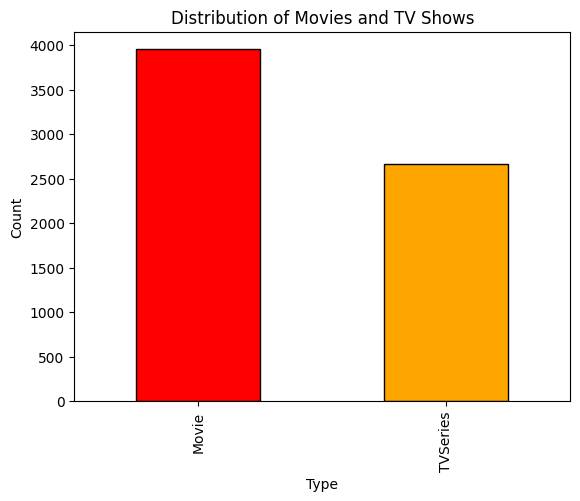

In [36]:
data['type'].value_counts().plot(kind = 'bar', color = ['red', 'orange'], edgecolor = 'black')

plt.title('Distribution of Movies and TV Shows')
plt.xlabel('Type')
plt.ylabel('Count')

plt.show()

### content released  by year


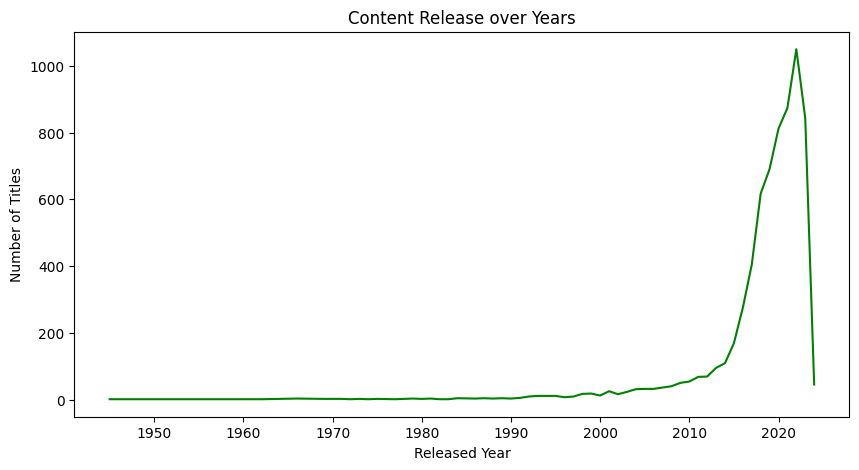

In [39]:
data['release_year'].value_counts().sort_index().plot(figsize=(10,5), color = 'green')

plt.title('Content Release over Years')
plt.xlabel('Released Year')
plt.ylabel('Number of Titles')  

plt.show()


### top genres


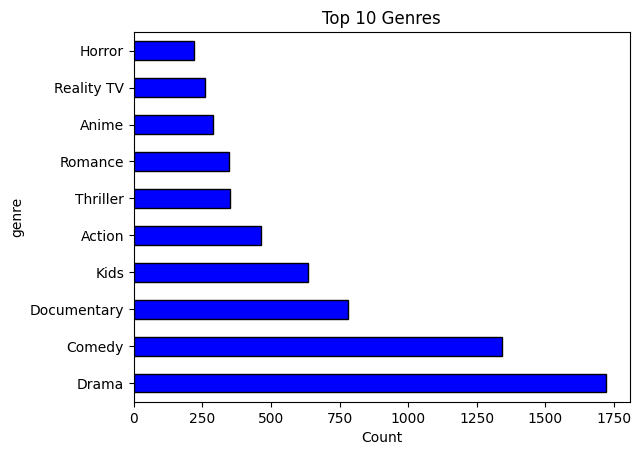

In [41]:
data['genre'].value_counts().head(10).plot(kind='barh', color='blue', edgecolor='black')

plt.title('Top 10 Genres')
plt.xlabel('Count')

plt.show()

### Rating Distribution

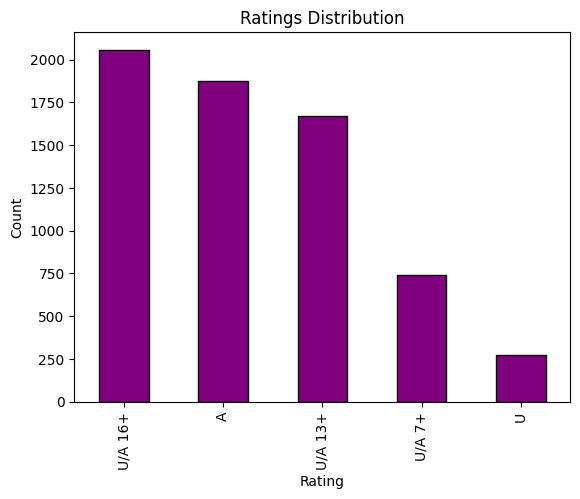

In [44]:
data['rating'].value_counts().plot(kind='bar', color='purple', edgecolor='black')

plt.title('Ratings Distribution')
plt.xlabel('Rating')
plt.ylabel('Count')

plt.show()

### top production  countries

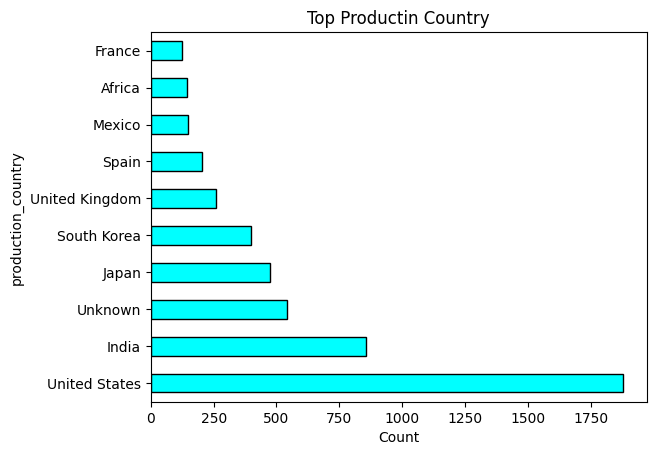

In [45]:
data['production_country'].value_counts().head(10).plot(kind='barh', color='cyan', edgecolor='black')

plt.title('Top Productin Country')
plt.xlabel('Count')

plt.show()

### Audio Language 

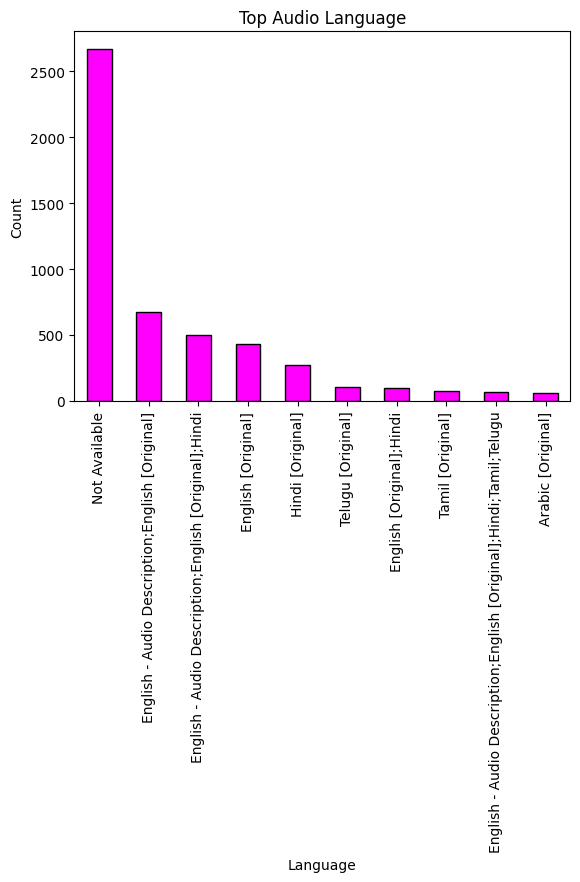

In [46]:
data['audio'].value_counts().head(10).plot(kind='bar', color='magenta', edgecolor='black')

plt.title('Top Audio Language')
plt.xlabel('Language')
plt.ylabel('Count')

plt.show()


### Subtitle Availability

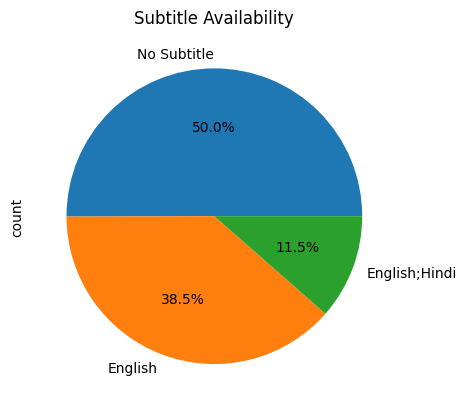

In [26]:
data['subtitles'].value_counts().head(3).plot(kind='pie', autopct='%1.1f%%')
plt.title('Subtitle Availability')
plt.show()

# Conclusion



In this project, Netflix content data was cleaned and analyzed using Python. Missing values were handled, duplicates were checked, and data types were corrected to improve data quality.

Key Findings:
- Movies were more common than TV Shows in the dataset.
- U/A 16+ was the most frequent content rating, followed by Adult-only content.
- The United States was the leading production country, while India ranked second.
- Certain genres were more dominant, showing Netflix's focus on specific content categories.
- Content releases increased significantly in recent years, indicating the growth of streaming platforms.
- Multiple audio language options and subtitle availability highlight Netflix's focus on serving a global audience.

Overall, the analysis provided valuable insights into Netflix's content distribution, audience targeting, production trends, and viewing accessibility.